<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/fields/05_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Field 5 · Computer vision · taste project*

# How does a model find and recognise things in an image?

> **In short**
>
> **How does a model find and recognise things in an image?**
>
> It slides small grids of weights, called filters, across the image. Early filters find edges. Later layers combine edges into shapes and shapes into objects. A CNN learns those filters from examples.

## Where you'll end up

By the end you will have built:

1. **An edge detector, by hand**: a 3 × 3 filter sliding over a photo.
2. **A convolutional network (CNN)** that recognises 10 kinds of clothing from small pictures.
3. **Pictures of what it learned**: its filters, and what each one picks out of an image.

Running every cell takes about 3 minutes on a CPU.

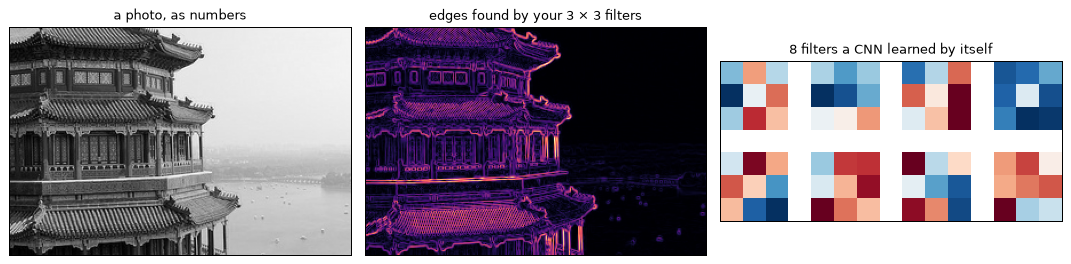

## How to use this notebook

- Run each grey code cell with **Shift + Enter**, top to bottom.
- 🤔 **Predict first** boxes ask you to guess before you run. The answer is one click away.
- 🐍 **Python notes** explain Python as it comes up.
- Exercise solutions are in collapsed cells. In Colab, double-click a solution's title to open it.

## 1. The problem: a photo is only numbers

To a computer, a photo is a grid. Each pixel is three numbers (red, green, blue) from 0 to 255.
A cat, a shirt, a temple: all of them grids of numbers.

**Before a program can recognise anything, it has to find structure in the grid.** The simplest structure is an **edge**: a place where dark turns to light.

colour photo: (427, 640, 3)   grey photo: (427, 640)


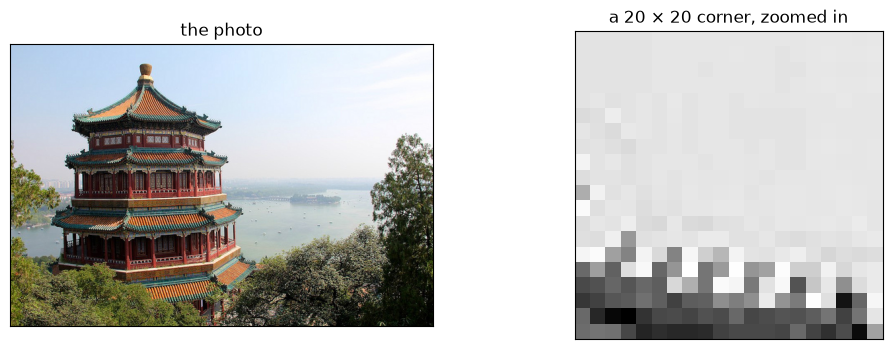

[[0.9  0.9  0.9  0.9  0.9  0.9 ]
 [0.9  0.9  0.9  0.89 0.9  0.9 ]
 [0.9  0.9  0.9  0.9  0.9  0.9 ]
 [0.9  0.9  0.9  0.9  0.9  0.9 ]
 [0.9  0.91 0.89 0.9  0.9  0.9 ]
 [0.87 0.88 0.93 0.89 0.9  0.9 ]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image

photo = load_sample_image("china.jpg")                 # a photo that ships with scikit-learn
gray = photo.mean(axis=2) / 255.0                       # average the red, green and blue: one number per pixel
print("colour photo:", photo.shape, "  grey photo:", gray.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(photo); axes[0].set_title("the photo")
axes[1].imshow(gray[100:120, 300:320], cmap="gray"); axes[1].set_title("a 20 × 20 corner, zoomed in")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.show()
print(np.round(gray[100:106, 300:306], 2))

🐍 **Python notes**
- `photo.shape` is `(427, 640, 3)`: rows, columns, colours. `photo.mean(axis=2)` averages along the colour axis, leaving `(427, 640)`.
- `gray[100:120, 300:320]` cuts out rows 100–119 and columns 300–319: **slicing** in two directions at once.

## 2. Find edges with a 3 × 3 filter

Take a 3 × 3 patch of the image. Multiply each pixel by the matching number in a 3 × 3 **filter**, and add up the nine results.
Slide the patch one pixel across and repeat, everywhere. The results form a new image.

This filter has −1s on the left and +1s on the right:

$$\begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$

Over a flat patch, the left and right cancel: output near 0. Where the left is dark and the right is light, they don't cancel: a big output.

### 🤔 Predict first

This filter compares left with right. **Will it light up vertical edges (like a door frame) or horizontal ones (like a roof line)?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**Vertical edges.** It compares pixels to the left and right of each point, so it responds where brightness changes from left to right, which happens along vertical lines.

</details>

two filters over 60,000 pixels with Python loops: 0.28s


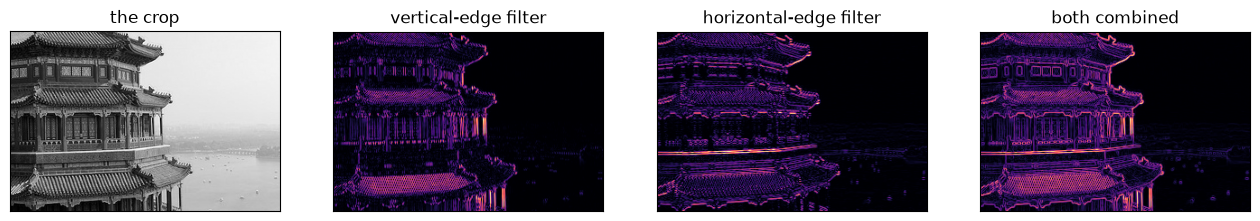

In [2]:
def convolve(image, filt):
    """Slide a 3x3 filter over the image. Each output = sum of (patch x filter)."""
    H, W = image.shape
    out = np.zeros((H - 2, W - 2))
    for i in range(H - 2):
        for j in range(W - 2):
            out[i, j] = (image[i:i + 3, j:j + 3] * filt).sum()
    return out

VERTICAL = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])
HORIZONTAL = VERTICAL.T

import time
crop = gray[100:300, 150:450]
t0 = time.time()
edges_v = convolve(crop, VERTICAL)
edges_h = convolve(crop, HORIZONTAL)
print(f"two filters over {crop.size:,} pixels with Python loops: {time.time() - t0:.2f}s")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, img, title in [(axes[0], crop, "the crop"), (axes[1], np.abs(edges_v), "vertical-edge filter"),
                       (axes[2], np.abs(edges_h), "horizontal-edge filter"), (axes[3], np.hypot(edges_v, edges_h), "both combined")]:
    ax.imshow(img, cmap="gray" if title == "the crop" else "magma"); ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.show()

🐍 **Python notes**
- `image[i:i + 3, j:j + 3] * filt` multiplies two 3 × 3 arrays item by item; `.sum()` adds the nine results.
- `VERTICAL.T` is the **transpose**: rows become columns. A left-right filter becomes a top-bottom one.
- `np.hypot(a, b)` is $\sqrt{a^2 + b^2}$, item by item: the overall edge strength.

**What it's called:** sliding a filter over an image is a **convolution**. The filter is also called a **kernel**, and the output image is a **feature map**. This particular filter is the **Sobel** filter.

$$\cy{\text{out}}[i, j] = \sum_{a=0}^{2}\sum_{b=0}^{2} \cr{w}[a, b]\; \cg{x}[i + a,\, j + b]$$

### The same thing, without loops

The Python loop is slow. The same sum can be done as nine whole-image multiplies, one per filter cell.

In [3]:
def convolve_fast(image, filt):
    H, W = image.shape
    out = np.zeros((H - 2, W - 2))
    for a in range(3):
        for b in range(3):
            out += filt[a, b] * image[a:a + H - 2, b:b + W - 2]     # shift the whole image, scale, add
    return out

t0 = time.time()
fast = convolve_fast(crop, VERTICAL)
print(f"vectorised: {time.time() - t0:.4f}s   same answer: {np.allclose(fast, edges_v)}")

vectorised: 0.0011s   same answer: True


**What it's called:** moving a fixed-size window across a grid is a **sliding-window** algorithm. Writing it as whole-array operations is **vectorisation**: same arithmetic, done by numpy's fast compiled loops instead of Python's.

### Exercise 1

By hand: one row of pixels is `0 0 0 1 1 1`. A one-row filter is `−1 0 1`. Slide it along, keeping it fully on the row. **What are the outputs?**

<details><summary><b>Show the answer to exercise 1</b></summary>

Four positions: $0$, $1$, $1$, $0$. The two 1s sit either side of the jump from 0 to 1: the edge.

</details>

## 3. Let the network choose its own filters

You picked the Sobel filter by hand. For recognising a shirt or a sneaker, which filters are right? Nobody knows in advance.

A **convolutional neural network** (**CNN**) starts with random filters and adjusts them by gradient descent, like any other weights.
Here it learns from **Fashion-MNIST**: 60,000 small (28 × 28) grey pictures of clothing in 10 kinds.

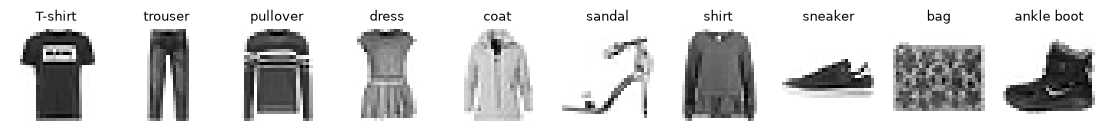

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

torch.manual_seed(0)
train = torchvision.datasets.FashionMNIST("data", train=True, download=True)
test = torchvision.datasets.FashionMNIST("data", train=False, download=True)
X, y = train.data.float().div(255).unsqueeze(1), train.targets
Xt, yt = test.data.float().div(255).unsqueeze(1), test.targets
NAMES = ["T-shirt", "trouser", "pullover", "dress", "coat", "sandal", "shirt", "sneaker", "bag", "ankle boot"]

fig, axes = plt.subplots(1, 10, figsize=(14, 1.8))
for d, ax in enumerate(axes):
    ax.imshow(X[(y == d).nonzero()[0, 0], 0], cmap="gray_r"); ax.set_title(NAMES[d], fontsize=9); ax.axis("off")
plt.show()

In [5]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)      # 8 filters, 3x3, on the grey image
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)     # 16 filters, each looking at all 8 feature maps
        self.fc = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)      # 28x28 -> 14x14
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)      # 14x14 -> 7x7
        return self.fc(x.flatten(1))

def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        pred = torch.cat([model(X[i:i + 1000]).argmax(1) for i in range(0, len(X), 1000)])
    model.train()
    return (pred == y).float().mean().item(), pred

model = SmallCNN()
print("weights:", sum(p.numel() for p in model.parameters()))
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
t0 = time.time()
for epoch in range(3):
    order = torch.randperm(len(X))
    for i in range(0, len(X), 64):
        b = order[i:i + 64]
        loss = F.cross_entropy(model(X[b]), y[b])
        opt.zero_grad(); loss.backward(); opt.step()
    acc, pred = evaluate(model, Xt, yt)
    print(f"epoch {epoch + 1}: test accuracy {acc:.1%}  ({time.time() - t0:.0f}s)")

weights: 9098


epoch 1: test accuracy 86.7%  (4s)


epoch 2: test accuracy 87.9%  (8s)


epoch 3: test accuracy 88.7%  (12s)


**What it's called:** `max_pool2d(..., 2)` keeps the biggest number in each 2 × 2 block, halving the size. That is **pooling**: it keeps "is the pattern here?" and drops "exactly where".
The filters in `conv1` and `conv2` started random; every one was adjusted by backpropagation.

### 🤔 Predict first

**Which two kinds of clothing do you think the CNN confuses most?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

Usually **shirt** with **T-shirt**, **pullover** or **coat**: at 28 × 28 pixels, they have similar outlines. Run the next cell to see the confusion table.

</details>

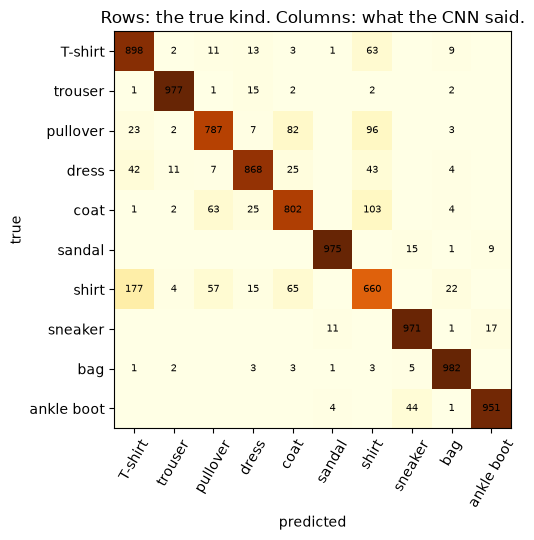

most common mistake: shirt read as T-shirt (177 times)


In [6]:
conf = np.zeros((10, 10), int)
for t, p in zip(yt.tolist(), pred.tolist()):
    conf[t, p] += 1
plt.figure(figsize=(6.5, 5.5))
plt.imshow(conf, cmap="YlOrBr")
plt.xticks(range(10), NAMES, rotation=60); plt.yticks(range(10), NAMES)
plt.xlabel("predicted"); plt.ylabel("true")
for i in range(10):
    for j in range(10):
        if conf[i, j]: plt.text(j, i, conf[i, j], ha="center", va="center", fontsize=7)
plt.title("Rows: the true kind. Columns: what the CNN said."); plt.tight_layout(); plt.show()
off = conf.copy(); np.fill_diagonal(off, 0)
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"most common mistake: {NAMES[i]} read as {NAMES[j]} ({off[i, j]} times)")

A table like this, of true answers against predictions, is a **confusion matrix**.

## 4. What did it learn?

The first layer's filters are 3 × 3 grids of weights, like your Sobel filter. Red is positive, blue negative.
Below them: what each filter picks out of one picture.

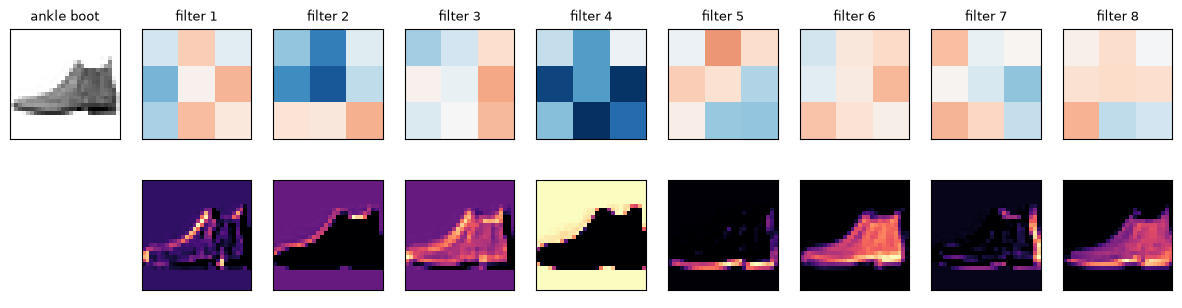

In [7]:
w = model.conv1.weight.detach()[:, 0]
img = Xt[0:1]
with torch.no_grad():
    maps = F.relu(model.conv1(img))[0]

fig, axes = plt.subplots(2, 9, figsize=(15, 3.6))
axes[0, 0].imshow(img[0, 0], cmap="gray_r"); axes[0, 0].set_title(NAMES[yt[0]], fontsize=9)
axes[1, 0].axis("off")
for k in range(8):
    axes[0, k + 1].imshow(w[k], cmap="RdBu_r", vmin=-w.abs().max(), vmax=w.abs().max())
    axes[0, k + 1].set_title(f"filter {k + 1}", fontsize=9)
    axes[1, k + 1].imshow(maps[k], cmap="magma")
for ax in axes.flat: ax.set_xticks([]); ax.set_yticks([])
plt.show()

**What you see:** several filters look like edge detectors (a row or column of red next to blue). Their feature maps light up along the outline of the item.
Some respond to flat bright areas. Nobody told the network to build edge detectors; edges turned out to be useful for telling clothing apart.

### Checking your convolution against PyTorch's

PyTorch's `F.conv2d` is the same sliding sum. (It flips nothing; strictly, it computes what mathematicians call cross-correlation, as your code does.)

In [8]:
filt = w[0].numpy()
mine = convolve_fast(img[0, 0].numpy(), filt)
theirs = F.conv2d(img, w[0:1, None])[0, 0].numpy()          # no padding: same size as yours
print("largest difference:", float(np.abs(mine - theirs).max()))

largest difference: 8.42846930027008e-08


## 5. Two tricks used everywhere

**Data augmentation.** Make extra training examples by changing the ones you have in ways that don't change the answer: shift, flip, rotate slightly. A shirt flipped left-to-right is still a shirt.

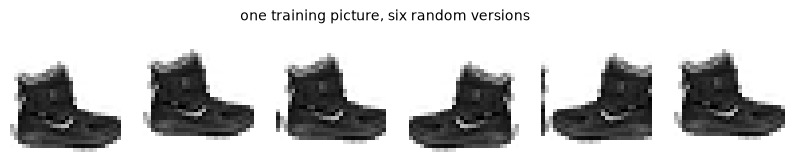

In [9]:
def augment(x):
    flip = torch.rand(len(x)) < 0.5
    x = torch.where(flip[:, None, None, None], x.flip(-1), x)              # mirror half the batch
    shift = torch.randint(-2, 3, (2,))
    return torch.roll(x, shifts=(int(shift[0]), int(shift[1])), dims=(2, 3))  # move by up to 2 pixels

fig, axes = plt.subplots(1, 6, figsize=(10, 1.8))
for ax in axes:
    ax.imshow(augment(X[:1])[0, 0], cmap="gray_r"); ax.axis("off")
plt.suptitle("one training picture, six random versions", fontsize=10); plt.show()

**Transfer learning.** Big CNNs trained on millions of photos learn general filters (edges, textures, parts). You can take one, replace its last layer, and train only that layer on your own small dataset.
In Colab you can try it: `torchvision.models.resnet18(weights="DEFAULT")` downloads such a network (about 45 MB).

## Practice

Try each one before opening its solution.

### Exercise 2

Design a 3 × 3 filter that responds to **diagonal** edges running from the top-left to the bottom-right, and show its output on the photo crop.

In [10]:
DIAG = np.array([[0, 0, 0],
                 [0, 0, 0],
                 [0, 0, 0]])   # your numbers here

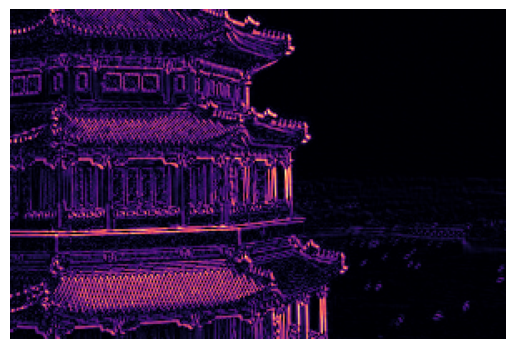

In [11]:
#@title Solution to exercise 2 (double-click to show)
DIAG = np.array([[ 0,  1, 2],
                 [-1,  0, 1],
                 [-2, -1, 0]])
plt.imshow(np.abs(convolve_fast(crop, DIAG)), cmap="magma"); plt.axis("off"); plt.show()
# Positive cells above the diagonal, negative below: it compares one side of the diagonal with the other.

### Exercise 3

Train the CNN again **with** `augment` applied to every batch, for the same 3 epochs. **Does test accuracy go up or down?** Why might it differ on this dataset?

In [12]:
# your experiment here

In [13]:
#@title Solution to exercise 3 (double-click to show)
torch.manual_seed(0)
m2 = SmallCNN(); o2 = torch.optim.Adam(m2.parameters(), lr=2e-3)
for epoch in range(3):
    order = torch.randperm(len(X))
    for i in range(0, len(X), 64):
        b = order[i:i + 64]
        loss = F.cross_entropy(m2(augment(X[b])), y[b])
        o2.zero_grad(); loss.backward(); o2.step()
print("with augmentation:", f"{evaluate(m2, Xt, yt)[0]:.1%}")
# Often about the same or slightly lower after 3 epochs: every Fashion-MNIST picture is already centred,
# so shifted training pictures are harder than the test ones. Augmentation helps most when real inputs vary.

with augmentation: 85.3%


## Recognition cues

- When you see **"find a small pattern anywhere in an image"** in a problem, think **a convolution (a filter sliding over the image)**.
- When you see **a 2-D grid and a window that moves across it** in a problem, think **a sliding-window loop, then vectorise it**.
- When you see **"the same object could appear anywhere in the picture"** in a problem, think **share one filter's weights across all positions (a CNN)**.
- When you see **"we only have a few hundred labelled images"** in a problem, think **transfer learning and data augmentation**.

## Try changing this

1. **Wider first layer.** Give `conv1` 32 filters instead of 8. Does accuracy improve? Do the extra filters look different?
2. **No pooling.** Remove both `max_pool2d` calls (and fix the size of `fc`). How much slower is training, and does accuracy change?
3. **Your own photo.** Upload a photo in Colab (left sidebar → Files), load it with `plt.imread`, and run your edge filters on it.

## Open research questions

People are working on these right now:

- How do models understand 3D scenes from flat images?
- How do they handle situations they've never seen?

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **Computer vision** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.

## Go deeper

- Stanford CS231n course notes (free; start with "Convolutional Neural Networks"): https://cs231n.github.io/
- At Monash: FIT5221 Intelligent image and video analysis.